# Creating a warehouse agent that uses the tools and DB table created before

In [1]:
from pydantic import BaseModel

from langchain_openai import ChatOpenAI

from langsmith import traceable

import instructor

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode


from langchain_core.messages import SystemMessage, convert_to_openai_messages, HumanMessage, AIMessage
from IPython.display import Image, display

from typing import Any, Annotated, List
from pydantic import Field
from operator import add

from jinja2 import Template

from utils.tools import PRODUCT_TOOLS, SHOPPING_CART_TOOLS, WAREHOUSE_TOOLS

/Users/dom/Documents/GitHub/e2e-engineering-course/E2E-AI-Engineering-Bootcamp/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 105/105 [00:00<00:00, 7907.25it/s]
/Users/dom/Documents/GitHub/e2e-engineering-course/E2E-AI-Engineering-Bootcamp/.venv/lib/python3.12/site-packages/langsmith/run_helpers.py:546: UserWarning: Unrecognized run_type: sql. Must be one of: {'prompt', 'parser', 'retriever', 'llm', 'tool', 'chain', 'embedding'}. Did you mean @traceable(name='sql')?
  warnings.warn(
/Users/dom/Documents/GitHub/e2e-engineering-course/E2E-AI-Engineering-Bootcamp/.venv/lib/python3.12/site-packages/langsmith/run_helpers.py:546: UserWarning: Unrecognized run_type: sql. Must be one of: {'prompt', 'parser', 'retriever', 'llm', 'tool', 'chain', 'embedding'}. Did you mean

## Worker Agents

In [2]:
# state for product Q&A agent
class RagUsedContext(BaseModel):
    id: str = Field(description="ID of the item used to answer the question")
    description: str = Field(description="Description of the item used to answer the question")

class FinalQnAResponse(BaseModel):
    answer: str = Field(description="Final answer to the question")
    citations: list[RagUsedContext] = Field(description="List of items that were relevant to create the final answer")


In [3]:
# State for shopping agent
class FinalAgentResponse(BaseModel):
    answer: str = Field(description="Answer to the question")

In [4]:
# state for Coordinator Agent
class Delegation(BaseModel):
    agent: str = Field(description="Agent to delegate the task to")
    task: str = Field(description="The task that the agent should perform")

class Plan(BaseModel):
    next_agent: str = Field(description="The next agent that should be invoked")
    plan: List[Delegation] = Field(description="A list of delevations to agents with tasks to be performed in sequence")

In [5]:
# overarching global state
class AgentProperties(BaseModel):
    iteration: int = 0
    final_answer: bool = False

class CoordinatorAgentProperties(BaseModel):
    iteration: int = 0
    final_answer: bool = False
    plan: List[Delegation] = []
    next_agent: str = ""


class State(BaseModel):
    messages: Annotated[List[Any], add] = []
    coordinator_agent_state: CoordinatorAgentProperties = CoordinatorAgentProperties()
    product_qna_agent_state: AgentProperties = AgentProperties()
    shopping_cart_agent_state: AgentProperties = AgentProperties()
    warehouse_manager_agent: AgentProperties = AgentProperties()
    citations: list[RagUsedContext] = []
    answer: str = ""
    user_intent: str = ""
    user_id: str = ""
    cart_id: str = ""

### Product Q&A agent

In [ ]:
from langchain_core.messages import AIMessage
@traceable(
    name="product_qna_agent_node",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def product_qna_agent_node(state: State) -> dict:
    jinja_prompt_template = """# Role: 
    - You are a shopping assistant that answers customer questions about the available products on our marketplace.

    # Goal: 
    - Give the customer a direct and polite answer to their question given the output of available tools. If the tools did not yield any relevant information mention that you are not able to find information on it, if there is no information in the context.

    # Instructions:
    - Use available tools to answer product related questions
    - Never fabricate information about products that are not mentioned in the context or through tool calls
    - When describing products use relevant details
    - If there are no products returned by any tools, ask the customer to rephrase their request and you were not able to find anything related to this request
    - If the customer doesn't state anything related to products in their request ask them to specify which product they are interested in
    - Refer to data in context always as "available products" and never as "context"
    - Try answering queries that are not precise by broadening the search radius i.e. product categories instead of specific brand
    """
    template = Template(jinja_prompt_template)

    prompt = template.render()

    llm_client = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="none",
        use_responses_api=True
    )

    llm_client_with_tools = llm_client.bind_tools(
        [*PRODUCT_TOOLS, FinalQnAResponse],
        tool_choice="required"
    )

    response = llm_client_with_tools.invoke([
        SystemMessage(content=prompt),
        *state.messages
    ])

    final_answer = False
    answer = ""
    citations = []


    def sanitise_repsonse(response):
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalQnAResponse":
                answer = tool_call.get("args").get("answer")
                break
                # removing any toolcall suggestions by doing so
        return AIMessage(content=answer)

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalQnAResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")
                citations.extend(tool_call.get("args").get("citations"))

                response = sanitise_repsonse(response)
                break

    return {
        "messages": [response],
        "product_qna_agent_state": {
            "iteration": state.product_qna_agent_state.iteration + 1,
            "final_answer": final_answer
        },
        "answer": answer,
        "citations": citations,
    }


### Shopping Cart agent

In [7]:
@traceable(
    name="shopping_cart_agent",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def shopping_cart_agent(state) -> dict:
    
    prompt_template = """You are a part of the shopping assistant that can manage the user's shopping cart.

## Instructions

- Use names specificly provided in the available tools. Don't add any additional text to the names.
- You can run multipple tools at once.
- As the final answer you should return an answer in a form of actions performed.

## Additional information about the user

- User ID: {{ user_id }}
- Cart ID: {{ cart_id }}
"""

    template = Template(prompt_template)

    prompt = template.render(
        user_id=state.user_id,
        cart_id=state.cart_id
    )

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="low",
        use_responses_api=True
    )
    llm_with_tools = llm.bind_tools(
        [*SHOPPING_CART_TOOLS, FinalAgentResponse],
        tool_choice="required"
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
            *state.messages
        ]
    )

    final_answer = False
    answer = ""

    def sanitise_response(response):

        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalAgentResponse":
                answer = tool_call.get("args").get("answer")

        return AIMessage(content=answer)

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalAgentResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")

                response = sanitise_response(response)

    return {
        "messages": [response],
        "shopping_cart_agent_state": {
            "iteration": state.shopping_cart_agent_state.iteration + 1,
            "final_answer": final_answer
        },
        "answer": answer
    }

### Warehouse Agent

In [8]:
@traceable(
    name="warehouse_manager_agent",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def warehouse_manager_agent(state) -> dict:
    
    prompt_template = """You are a part of the shopping assistant that can manage available inventory in the warehouses.

## Instructions

- As the final answer you should return an answer to the users query in a form of actions performed.
- You must always check the availability of the items in the warehouses before reserving them.
- Only reserve items in warehouses if entire order can be reserved or the user has confirmed that they want a partial reservation.
- If you cannot reserve any items, return an answer that the order cannot be reserved.
- If you can reserve some items, return an answer that the order can be partially reserved and include the details.
- If only partial quantity can be reserved in some warehouses, try to combine the required quantity from different warehouses.
- Try to reserve items from the closest warehouse to the user first if users location is provided.
- As the final answer you should return an answer in a form of actions performed.
"""

    template = Template(prompt_template)

    prompt = template.render()

    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="low",
        use_responses_api=True
    )
    llm_with_tools = llm.bind_tools(
        [*WAREHOUSE_TOOLS, FinalAgentResponse],
        tool_choice="required"
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
            *state.messages
        ]
    )

    final_answer = False
    answer = ""

    def sanitise_response(response):

        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalAgentResponse":
                answer = tool_call.get("args").get("answer")

        return AIMessage(content=answer)

    if len(response.tool_calls) > 0:
        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalAgentResponse":
                final_answer = True
                answer = tool_call.get("args").get("answer")

                response = sanitise_response(response)

    return {
        "messages": [response],
        "warehouse_manager_agent": {
            "iteration": state.warehouse_manager_agent.iteration + 1,
            "final_answer": final_answer
        },
        "answer": answer
    }


## Coordinator Agent

In [9]:
@traceable(
    name="coordinator_agent",
    run_type="llm",
    metadata={
        "ls_provider": "openai",
        "ls_model_name": "gpt-5.4-mini"
    }
)
def coordinator_agent(state) -> dict:
    
    prompt_template = """You are a coordinator agent as part of a shopping assisant.

    ## Role
    - You are responsible to create plans to solve the user query by delegating tasks to other agents
    - If none of the stated agents are helpful to answer the user query, than generate an answer yourself, that instructs the user to clarify or state that you cannot help with the query.

    ## Task
    - You get a conversation history with the user that should be used to understand the user request
    - You create a plan that uses the available agents to come to a final answer to the query
    - After the plan is created you should output the next agent to invoke and the task to be performed by that agent
    - Once an agent finishes a task it will report back to you, you should then decide if the plan needs any updates and what the next step will be
    - If a subagent has successfully completed the task and answered the user query in the conversation history, do not delegate or plan further. You must call FinalAgentResponse to return the subagent's answer as the final response to the user.
    - If there is a sequence of tasks to be performed by one agent you should combine them into a single task
    - Do not route to any agents if the user request is unclear or irrelevant for the shopping assistant with the given agents

    ## Available Agents
    ### product_qna_agent:
    - user query relates to products, inventory or purchasing
    - Queries about product specs, features, availability, pricing, comparisons, ratings and recommendations
    - if the query is about an item that should be added, deleted or shown in the shopping cart it is not a product_q&a question, but rather a shopping_cart query 
    
    ### shopping_cart_agent:
    - queries to add, list or delete items from a shopping cart
    - questions about products in the shopping cart are not part of the shopping_cart, they belong to the product_q&a questions

    ### warehouse_agent: 
    - The user is asking to reserve items from the warehouses or about availability of the items in warehouses

    ## Examples:
    <example>
    Question: "Do you have books under 20USD?"
    Next Agent: product_gna_agent
    </example>

    <example>
    Question: "I don't want to buy the Shoes anymore"
    Next Agent: shopping_cart_agent
    </example> 

    <example>
    Question: "Please reserve my shopping cart items"
    Next Agent: warehouse_agent
    </example>
    
    <example>
    Question: "Do you have books under 20USD?"
    History:
    - User: Do you have books under 20USD?
    - product_qna_agent (FinalQnAResponse): Yes, we have Book A for 15USD.
    Next Agent: FinalAgentResponse(answer="Yes, we have Book A for 15USD.")
    </example>
"""

    template = Template(prompt_template)

    prompt = template.render(
        user_id=state.user_id,
        cart_id=state.cart_id
    )

    # guard condition if the coordinator is invoked with the final answer from a subagent (AIMessage without tool_calls)
    if len(state.messages) > 0 and \
       isinstance(state.messages[-1], AIMessage) and \
       len(state.messages[-1].tool_calls) == 0:
       
        last_msg = state.messages[-1]
        if isinstance(last_msg.content, list):
            answer = ""
            for item in last_msg.content:
                if isinstance(item, dict):
                    if item.get("type") == "text":
                        answer += item.get("text", "")
                elif isinstance(item, str):
                    answer += item
        else:
            answer = last_msg.content
        return {
            "messages": [],
            "coordinator_agent_state": {
                "iteration": state.coordinator_agent_state.iteration + 1,
                "final_answer": True,
                "plan": state.coordinator_agent_state.plan,
                "next_agent": ""
            },
            "answer": answer
        }

    # core logic if it is not a final answer
    llm = ChatOpenAI(
        model="gpt-5.4-mini",
        reasoning_effort="low",
        use_responses_api=True
    )
    llm_with_tools = llm.bind_tools(
        [Plan, FinalAgentResponse],
        tool_choice="required"
    )

    response = llm_with_tools.invoke(
        [
            SystemMessage(content=prompt),
            *state.messages
        ]
    )

    final_answer = False
    answer = ""
    plan = []
    next_agent = ""

    def sanitise_response(response):

        for tool_call in response.tool_calls:
            if tool_call.get("name") == "FinalAgentResponse":
                answer = tool_call.get("args").get("answer")

        return AIMessage(content=answer)

    if len(response.tool_calls) > 0:
        if response.tool_calls[0].get("name") == "Plan":
            plan = response.tool_calls[0].get("args").get("plan")
            next_agent = response.tool_calls[0].get("args").get("next_agent")
            response = None
        else:
            for tool_call in response.tool_calls:
                if tool_call.get("name") == "FinalAgentResponse":
                    final_answer = True
                    answer = tool_call.get("args").get("answer")

                    response = sanitise_response(response)

    return {
        "messages": [response] if response is not None else [],
        "coordinator_agent_state": {
            "iteration": state.coordinator_agent_state.iteration + 1,
            "final_answer": final_answer,
            "plan": plan,
            "next_agent": next_agent
        },
        "answer": answer
    }

## Graph

In [10]:
def coordinator_conditional_edges(state: State) -> dict:
    if state.coordinator_agent_state.final_answer:
        return "end"
    elif state.coordinator_agent_state.iteration > 5:
        return "end"
    elif state.coordinator_agent_state.next_agent != "": #return the name of the next agent directly
        return state.coordinator_agent_state.next_agent # in prod should check if the agent actually exists
    else:
        return "end"

In [11]:
def product_qna_tool_router_conditional_edges(state: State) -> dict:
    if state.product_qna_agent_state.final_answer:
        return "end"
    elif state.product_qna_agent_state.iteration >= 3:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [12]:
def shopping_cart_tool_router_conditional_edges(state: State) -> dict:
    if state.shopping_cart_agent_state.final_answer:
        return "end"
    elif state.shopping_cart_agent_state.iteration >= 3:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [13]:
def warehouse_manager_tool_conditional_edges(state: State) -> str:

    if state.warehouse_manager_agent.final_answer:
        return "end"
    elif state.warehouse_manager_agent.iteration >= 5:
        return "end"
    elif len(state.messages[-1].tool_calls) > 0:
        return "tools"
    else:
        return "end"

In [14]:
workflow = StateGraph(State)

product_tool_node = ToolNode(PRODUCT_TOOLS)
shopping_cart_tool_node = ToolNode(SHOPPING_CART_TOOLS)
warehouse_tool_node = ToolNode(WAREHOUSE_TOOLS)

# nodes
# coordinator agent
workflow.add_node("coordinator_agent_node", coordinator_agent)

#Product Q&A Agent
workflow.add_node("product_qna_agent_node", product_qna_agent_node)
workflow.add_node("product_tool_node", product_tool_node)

# Shopping Cart Agent
workflow.add_node("shopping_cart_agent_node", shopping_cart_agent)
workflow.add_node("shopping_cart_tool_node", shopping_cart_tool_node)

# Warehouse Agent
workflow.add_node("warehouse_agent_node", warehouse_manager_agent)
workflow.add_node("warehouse_tool_node", warehouse_tool_node)

# edges
workflow.add_edge(START, "coordinator_agent_node")
workflow.add_conditional_edges(
    "coordinator_agent_node",
    coordinator_conditional_edges,
    {
        "product_qna_agent": "product_qna_agent_node",
        "shopping_cart_agent": "shopping_cart_agent_node",
        "warehouse_agent": "warehouse_agent_node",
        "end": END
    }
)
# product agent edges
workflow.add_conditional_edges(
    "product_qna_agent_node",
    product_qna_tool_router_conditional_edges,
    {
        "tools": "product_tool_node",
        "end": "coordinator_agent_node"
    }
)
workflow.add_edge("product_tool_node", "product_qna_agent_node")

# shopping cart edges
workflow.add_conditional_edges(
    "shopping_cart_agent_node",
    shopping_cart_tool_router_conditional_edges,
    {
        "tools": "shopping_cart_tool_node",
        "end": "coordinator_agent_node"
    }
)
workflow.add_edge("shopping_cart_tool_node", "shopping_cart_agent_node")


# warehouse edges
workflow.add_conditional_edges(
    "warehouse_agent_node",
    warehouse_manager_tool_conditional_edges,
    {
        "tools": "warehouse_tool_node",
        "end": "coordinator_agent_node"
    }
)
workflow.add_edge("warehouse_tool_node", "warehouse_agent_node")

graph = workflow.compile()


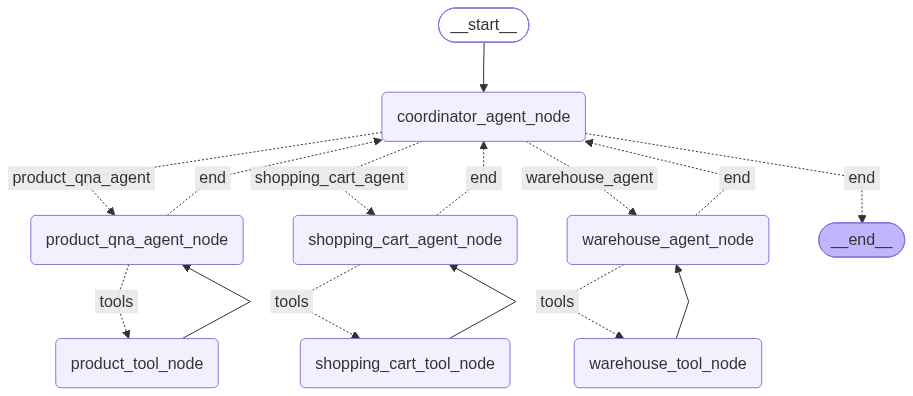

In [15]:
display(Image(
    graph.get_graph().draw_mermaid_png()
))

### State Streaming

In [16]:
import os 
from langgraph.checkpoint.postgres import PostgresSaver

# setup postgres DB
db = os.environ["MULTI_TURN_POSTGRES_DB"]
user = os.environ["MULTI_TURN_POSTGRES_USER"]
password = os.environ["MULTI_TURN_POSTGRES_PASSWORD"]
HOST = "localhost"
PORT = "5432"

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    checkpointer.setup()

In [17]:
def process_graph_events(chunk):
    """Process debug events to display user friendly state updates"""
    def _is_node_start(chunk):
        return chunk[1].get("type") == "task"
    
    def _tool_to_text(tool_call):
        if tool_call.get("name") == "retrieve_formatted_products":
            return f"Looking for items: {tool_call.get("args").get("query", "")}" 
        elif tool_call.get("name") == "retrieve_prefiltered_reviews":
            return f"Looking for user reviews..." 
        
    if _is_node_start(chunk):
        if chunk[1].get("payload", {}).get("name") == "agent_node":
            print("Planning...")
                
        elif chunk[1].get("payload", {}).get("name") == "tool_node":
            message = " ".join([_tool_to_text(tool_call) for tool_call in chunk[1].get('payload', {}).get('input', {}).messages[-1].tool_calls])
            print(message)

In [18]:
initial_state = {
    "messages": [HumanMessage(content="Can you give me a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?")],
}

config = {
    "configurable": {
        "thread_id": "000000000067"
    }
}

chunks = []

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)

    for chunk in graph.stream( #dont invoke but rather stream the events from the graph
        initial_state,
        config=config,
        stream_mode=["values"]
    ):
        chunks.append(chunk)
        process_graph_events(chunk)


In [19]:
chunks[-1][1]

{'messages': [HumanMessage(content='Can you give me a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'arguments': '{"query":"kid tablet watch for wife waterproof speaker pool party family gifts electronics", "k":10}', 'call_id': 'call_uijXndPDAZE8FXSNTjEuhbSZ', 'name': 'retrieve_formatted_context', 'type': 'function_call', 'id': 'fc_0be659ad62876f12006a7ae35bc844819c8da8137e4fd4dae0', 'status': 'completed'}, {'arguments': '{"query":"children tablet smartwatch women\'s watch waterproof bluetooth speaker outdoor pool party", "k":10}', 'call_id': 'call_JABxKoIQ8i1vpdHeYIgLv2hO', 'name': 'retrieve_formatted_context', 'type': 'function_call', 'id': 'fc_0be659ad62876f12006a7ae35bc85c819ca3c3551368d4b305', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0be659ad62876f12006a7ae35aa308819c82e123bb5f866d37', 'created_at': 1786438490.0, 'metadata': {}, 'model': 'g

In [20]:
initial_state = {
    "messages": [HumanMessage(content="Please add all of these items to my cart and reserve them for me")],
    "user_id": "000000000000123",
    "cart_id": "000000000000123"
}

config = {
    "configurable": {
        "thread_id": "000000000067",
    }
}

chunks = []

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)

    for chunk in graph.stream( #dont invoke but rather stream the events from the graph
        initial_state,
        config=config,
        stream_mode=["values"]
    ):
        chunks.append(chunk)
        process_graph_events(chunk)


Deserializing unregistered type __main__.Delegation from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'Delegation')]
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('422 Client Error: unknown for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unprocessable entity: error parsing run for post.019ff009-30b0-76d3-8a7e-5874003e2f2e: schema validation failed: run_type: run_type must be one of the following: \\"tool\\", \\"chain\\", \\"llm\\", \\"retriever\\", \\"embedding\\", \\"prompt\\", \\"parser\\""}\n')


In [21]:
chunks[-1][1]

{'messages': [HumanMessage(content='Can you give me a tablet for my kid, a watch for my wife and a waterproof speaker for my pool party?', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'arguments': '{"query":"kid tablet watch for wife waterproof speaker pool party family gifts electronics", "k":10}', 'call_id': 'call_uijXndPDAZE8FXSNTjEuhbSZ', 'name': 'retrieve_formatted_context', 'type': 'function_call', 'id': 'fc_0be659ad62876f12006a7ae35bc844819c8da8137e4fd4dae0', 'status': 'completed'}, {'arguments': '{"query":"children tablet smartwatch women\'s watch waterproof bluetooth speaker outdoor pool party", "k":10}', 'call_id': 'call_JABxKoIQ8i1vpdHeYIgLv2hO', 'name': 'retrieve_formatted_context', 'type': 'function_call', 'id': 'fc_0be659ad62876f12006a7ae35bc85c819ca3c3551368d4b305', 'status': 'completed'}], additional_kwargs={}, response_metadata={'id': 'resp_0be659ad62876f12006a7ae35aa308819c82e123bb5f866d37', 'created_at': 1786438490.0, 'metadata': {}, 'model': 'g

The items were properly added to the shopping cart, but without a cart and user id (would need to be checked and would be handled under the hood without input from the user):
![Bildschirmfoto 2026-08-11.png](<attachment:Bildschirmfoto 2026-08-11.png>)

However, it looks like the warhouse_agent was never used, eventhough the coordinator planned for it
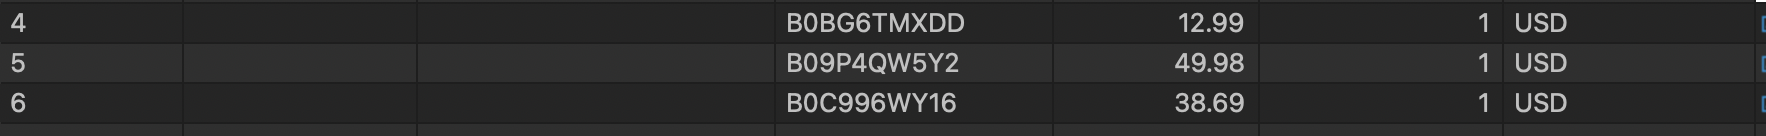

In [25]:
initial_state = {
    "messages": [HumanMessage(content="Look at the items in my shopping cart and reserve all of the items for me")],
    'user_id': '000000000000123',
    'cart_id': '000000000000123'
}

config = {
    "configurable": {
        "thread_id": "000000000069"
    }
}

chunks = []

with PostgresSaver.from_conn_string(
    f"postgresql://{user}:{password}@{HOST}:{PORT}/{db}"
    ) as checkpointer:
    graph = workflow.compile(checkpointer=checkpointer)

    for chunk in graph.stream( #dont invoke but rather stream the events from the graph
        initial_state,
        config=config,
        stream_mode=["values"]
    ):
        chunks.append(chunk)
        process_graph_events(chunk)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('422 Client Error: unknown for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unprocessable entity: error parsing run for post.019ff00e-83ec-7363-817b-29d68992d429: schema validation failed: run_type: run_type must be one of the following: \\"tool\\", \\"chain\\", \\"llm\\", \\"retriever\\", \\"embedding\\", \\"prompt\\", \\"parser\\""}\n')


In [26]:
chunks[-1][1]

{'messages': [HumanMessage(content='Look at the items in my shopping cart and reserve all of the items for me', additional_kwargs={}, response_metadata={}),
  AIMessage(content=[{'id': 'rs_0f355bc45ddc2626006a7ae4fe6d5c81a39b42bc920c1c954b', 'summary': [], 'type': 'reasoning', 'content': [], 'encrypted_content': 'gAAAAABqeuT-yThhrTBjjAg7zzvefrIcNaFkeUzmq2YBVV-3DGKae3iY1azgqMbXdNpyEFXYCLC7fa3oiW_GRy6C-Gg5Asf7SmyqJTbWEF5oH0A-6gNCbDBfeabIfMKoM9t3CNjB5ny1J36z7O0euL6bZhxsJlTOJGrTJmN-kabIk2JfO97JDvmh0K7psevmuO-D7Ftkzdl_4zvNRRmRBhYKyS-QnKbhn8ZRrj_wAa6AkRH3yN25Y-RJXbyT8j6ZToyQt-LY9Mr1uaktIf7BbTXrf-FVQ6v-RFQHxXfzTsx7tVVO1X85s6P3PGXJKm9ENOEN-l_qvs2Hx9AUaeSMHOvpNBCu2xbTIx8S8x7XGqIlCinVyPfmZgm3HWdOznSJgfvf0rRCYBmSgAOjghwbW0Itkl5GliCEXb2ysUtzJ8AiFEFbQrP8fApBqreetMVZxeO5vvU-josNWVnns8tD1KSbPOj4FMxLXHqAAL7QQHqcsy4YgqPa_hBpP0dmse5kjmd3JwZy_ZXMHjkfJTeL97M9AjiPje2aEIV7xX8RfZNFWA2anJSXv_P0WmdCpBHEFJz5tadlJ0iT0dkj_nw-09CsZR1oE-_YOmbin13sLIjKWT6VWX6xDEAL8RjXbCWt2I7Wk6cuQhrLOPJbxweljCB4JSrbZtQ5qTc3sjUYn-nfC

There definetly needs to be much more finetuning and examples to differentiate between the different available tools, the model is often confused